# Libs

In [11]:
%matplotlib widget

from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display

import pydicom as dcm
import numpy as np
import pandas as pd

import random

from sklearn.cluster import DBSCAN, KMeans

import cv2

# Paths

In [13]:
d_path = Path("../data/uncompressed/")

norma_name = "norma_anon"
pneumonia_name = "pneumonia_anon"
pneumothorax_name = "pneumotorax_anon"

norma_path = d_path / norma_name
pneumonia_path = d_path / pneumonia_name
pneumothorax_path = d_path / pneumothorax_name

norma_files = list(norma_path.glob("*"))
pneumonia_files = list(pneumonia_path.glob("*"))
pneumothorax_files = list(pneumothorax_path.glob("*"))
print(f"Normal files: {len(norma_files)}")
print(f"Pneumonia files: {len(pneumonia_files)}")
print(f"Pneumothorax files: {len(pneumothorax_files)}")

print(f"Normal size: {sum(f.stat().st_size for f in norma_files) / 1e6:.2f} MB")
print(f"Pneumonia size: {sum(f.stat().st_size for f in pneumonia_files) / 1e6:.2f} MB")
print(f"Pneumothorax size: {sum(f.stat().st_size for f in pneumothorax_files) / 1e6:.2f} MB")

Normal files: 451
Pneumonia files: 367
Pneumothorax files: 1
Normal size: 237.44 MB
Pneumonia size: 193.42 MB
Pneumothorax size: 249.85 MB


# Norma

In [14]:
norma_data = np.array([dcm.dcmread(f).pixel_array for f in norma_files])
print(f"Normal data shape: {norma_data.shape}")

Normal data shape: (451, 512, 512)


In [12]:
norma_vec = np.array([img.reshape(-1) for img in norma_data])
print(f"Normal data reshaped: {norma_vec.shape}")

Normal data reshaped: (451, 262144)


In [7]:
dbscan = DBSCAN(eps=3, min_samples=2, n_jobs=-1)
clusters = dbscan.fit_predict(norma_vec)
print(f"Clusters shape: {clusters.shape}")
print(f"Unique clusters: {np.unique(clusters)}")

Clusters shape: (451,)
Unique clusters: [-1]


In [59]:
kmeans = KMeans(n_clusters=7, n_init="auto", random_state=42)

clusters_km = kmeans.fit_predict(norma_vec)
pd.Series(clusters_km).value_counts().sort_index()

0     79
1     37
2     37
3    104
4     90
5     48
6     56
Name: count, dtype: int64

In [60]:
def show_cluster(cluster_idx):
    imgs = norma_data[clusters_km == cluster_idx]
    count = len(imgs)
    if count == 0:
        print(f"В кластере {cluster_idx} нет изображений.")
        return
    n = min(25, count)
    subset = random.sample(imgs.tolist(), n)
    fig, axes = plt.subplots(5, 5, figsize=(10, 10))
    for ax, img in zip(axes.flatten(), subset):
        ax.imshow(img, cmap="gray")
        ax.axis("off")
    for ax in axes.flatten()[n:]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

slider = widgets.IntSlider(
    value=0,
    min=clusters_km.min(),
    max=clusters_km.max(),
    step=1,
    description="Кластер:"
)
widgets.interact(show_cluster, cluster_idx=slider)

interactive(children=(IntSlider(value=0, description='Кластер:', max=6), Output()), _dom_classes=('widget-inte…

<function __main__.show_cluster(cluster_idx)>

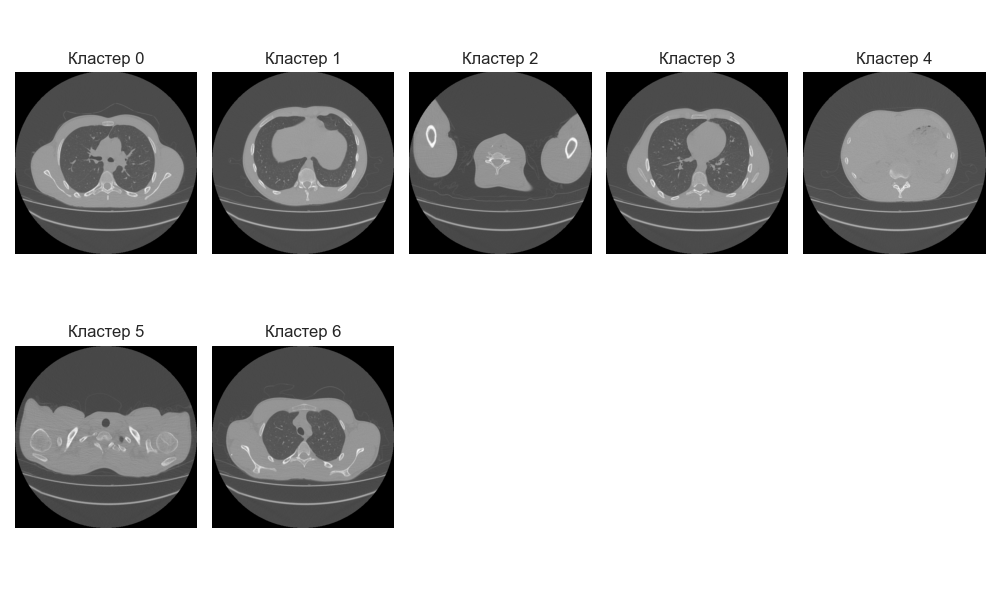

In [61]:
def show_image_from_each_cluster():
    unique_clusters = np.unique(clusters_km)
    n_clusters = len(unique_clusters)
    n_cols = 5
    n_rows = (n_clusters + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 3 * n_rows))
    axes = axes.flatten()

    for ax in axes:
        ax.axis("off")

    for idx, cluster_idx in enumerate(unique_clusters):
        imgs = norma_data[clusters_km == cluster_idx]
        if len(imgs) > 0:
            img = random.choice(imgs)
            ax = axes[idx]
            ax.imshow(img, cmap="gray")
            ax.set_title(f"Кластер {cluster_idx}")
            ax.axis("off")

    plt.tight_layout()
    plt.show()

show_image_from_each_cluster()

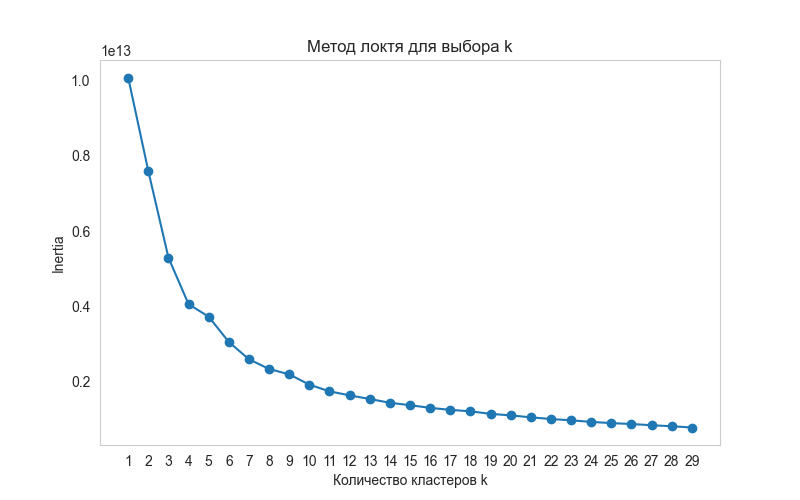

In [52]:
inertia = []
k_values = range(1, 30)
for k in k_values:
    kmeans = KMeans(n_clusters=k, n_init="auto", random_state=42)
    kmeans.fit(norma_vec)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker='o')
plt.title('Метод локтя для выбора k')
plt.xlabel('Количество кластеров k')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.grid()
plt.show()

In [ ]:
# TODO: Kmeans кластеризация классно определяет разные ракурсы

# Pneumonia

In [21]:
pneumonia_data = np.array([dcm.dcmread(f).pixel_array for f in pneumonia_files])
print(f"Pneumonia data shape: {pneumonia_data.shape}")

Pneumonia data shape: (367, 512, 512)


In [22]:
pneumonia_vec = np.array([img.reshape(-1) for img in pneumonia_data])
print(f"Pneumonia data reshaped: {pneumonia_vec.shape}")

Pneumonia data reshaped: (367, 262144)


In [23]:
kmeans_pneumonia = KMeans(n_init="auto", random_state=42)
clusters_km_pneumonia = kmeans_pneumonia.fit_predict(pneumonia_vec)
pd.Series(clusters_km_pneumonia).value_counts().sort_index()

0    47
1    37
2    32
3    67
4    42
5    50
6    34
7    58
Name: count, dtype: int64

In [25]:
def show_cluster_pneumonia(cluster_idx):
    imgs = pneumonia_data[clusters_km_pneumonia == cluster_idx]
    count = len(imgs)
    if count == 0:
        print(f"В кластере {cluster_idx} нет изображений.")
        return
    n = min(25, count)
    subset = random.sample(imgs.tolist(), n)
    fig, axes = plt.subplots(5, 5, figsize=(10, 10))
    for ax, img in zip(axes.flatten(), subset):
        ax.imshow(img, cmap="gray")
        ax.axis("off")
    for ax in axes.flatten()[n:]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

slider_pneumonia = widgets.IntSlider(
    value=0,
    min=clusters_km_pneumonia.min(),
    max=clusters_km_pneumonia.max(),
    step=1,
    description="Кластер:"
)
widgets.interact(show_cluster_pneumonia, cluster_idx=slider_pneumonia)

interactive(children=(IntSlider(value=0, description='Кластер:', max=7), Output()), _dom_classes=('widget-inte…

<function __main__.show_cluster_pneumonia(cluster_idx)>

# Pnemothorax

In [28]:
pneumothorax_data = np.array([dcm.dcmread(f).pixel_array for f in pneumothorax_files])[0]
print(f"Pneumothorax data shape: {pneumothorax_data.shape}")

Pneumothorax data shape: (476, 512, 512)


In [29]:
pneumothorax_vec = np.array([img.reshape(-1) for img in pneumothorax_data])
print(f"Pneumothorax data reshaped: {pneumothorax_vec.shape}")

Pneumothorax data reshaped: (476, 262144)


In [37]:
kmeans_pneumothorax = KMeans(n_init="auto", random_state=42)
clusters_km_pneumothorax = kmeans_pneumothorax.fit_predict(pneumothorax_vec)
pd.Series(clusters_km_pneumothorax).value_counts().sort_index()

0     57
1    128
2     34
3     77
4     37
5     54
6     47
7     42
Name: count, dtype: int64

In [39]:
def show_cluster_pneumothorax(cluster_idx):
    imgs = pneumothorax_data[clusters_km_pneumothorax == cluster_idx]
    count = len(imgs)
    if count == 0:
        print(f"В кластере {cluster_idx} нет изображений.")
        return
    n = min(25, count)
    subset = random.sample(imgs.tolist(), n)
    fig, axes = plt.subplots(5, 5, figsize=(10, 10))
    for ax, img in zip(axes.flatten(), subset):
        ax.imshow(img, cmap="gray")
        ax.axis("off")
    for ax in axes.flatten()[n:]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

slider_pneumothorax = widgets.IntSlider(
    value=0,
    min=clusters_km_pneumothorax.min(),
    max=clusters_km_pneumothorax.max(),
    step=1,
    description="Кластер:"
)
widgets.interact(show_cluster_pneumothorax, cluster_idx=slider_pneumothorax)

interactive(children=(IntSlider(value=0, description='Кластер:', max=7), Output()), _dom_classes=('widget-inte…

<function __main__.show_cluster_pneumothorax(cluster_idx)>

# All together

In [30]:
all_vec = np.vstack([norma_vec, pneumonia_vec, pneumothorax_vec])
print(f"All data shape: {all_vec.shape}")

All data shape: (1294, 262144)


In [32]:
# normalization
all_vec = all_vec.astype(np.float32)
all_vec -= all_vec.min()
all_vec /= all_vec.max()
print(f"All data normalized: min={all_vec.min()}, max={all_vec.max()}")

All data normalized: min=0.0, max=1.0


In [62]:
kmeans_all = KMeans(n_clusters=7, n_init="auto", random_state=42)
clusters_km_all = kmeans_all.fit_predict(all_vec)
pd.Series(clusters_km_all).value_counts().sort_index()

0    102
1    251
2    202
3     91
4    242
5    232
6    174
Name: count, dtype: int64

In [63]:
all_data = np.vstack([norma_data, pneumonia_data, pneumothorax_data])

In [64]:
def show_cluster_all(cluster_idx):
    imgs = all_data[clusters_km_all == cluster_idx]
    count = len(imgs)
    if count == 0:
        print(f"В кластере {cluster_idx} нет изображений.")
        return
    n = min(25, count)
    subset = random.sample(imgs.tolist(), n)
    fig, axes = plt.subplots(5, 5, figsize=(10, 10))
    for ax, img in zip(axes.flatten(), subset):
        ax.imshow(img, cmap="gray")
        ax.axis("off")
    for ax in axes.flatten()[n:]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()


slider_all = widgets.IntSlider(
    value=0,
    min=clusters_km_all.min(),
    max=clusters_km_all.max(),
    step=1,
    description="Кластер:"
)
widgets.interact(show_cluster_all, cluster_idx=slider_all)

interactive(children=(IntSlider(value=0, description='Кластер:', max=6), Output()), _dom_classes=('widget-inte…

<function __main__.show_cluster_all(cluster_idx)>